<div class="alert alert-info">
    <b>4.1 VAE Imputation (Data Rescue)</b><br><br>
    <b>Ziel:</b> Rettung von Datenpunkten, die in Schritt 2.4 aufgrund fehlender Werte verworfen wurden.<br>
    <b>Strategie:</b><br>
    1. <b>Lernen:</b> Ein Variational Autoencoder (VAE) lernt die geochemischen Zusammenhänge auf dem <b>bereinigten Datensatz</b> (aus 2.4 'Nach_IBF-und-Temp_Filter').<br>
    2. <b>Imputieren:</b> Das trainierte VAE wird genutzt, um fehlende Werte im <b>ursprünglichen Rohdatensatz</b> (aus 1.1 'Nach_Acquisition') aufzufüllen.<br>
    3. <b>Validieren:</b> Prüfung der Verteilungen und IBE.<br>
    <br>
    <b>Output:</b> 'Imputed_Data_Raw.csv' - Ein Datensatz mit aufgefüllten Lücken in Originaleinheiten.
</div>

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, QuantileTransformer
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re
import os
import pickle

# ------------------------- Reproduzierbarkeit -------------------------
torch.manual_seed(42)
np.random.seed(42)

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)


<div class="alert alert-info">
    <b>1. Daten Laden (Clean vs. Raw)</b>
</div>

In [2]:
# ------------------------- Pfade definieren -------------------------
base_dir = Path.cwd()
if base_dir.name != "4.1_Imputation":
    # Fallback für Entwicklung, falls Notebook nicht im richtigen Ordner gestartet wurde
    # (Anpassen je nach Umgebung)
    pass

notebooks_root = base_dir.parents[1]

# ------------------------- Pfad 1: Bereinigte Daten (Training) - Output 2.4 -------------------------
clean_db_root = notebooks_root / "1_Acquisition" / "1.1_Data-Acquisition-Wrapper" / "Angepasste_Datenbanken" / "Nach_IBF-und-Temp_Filter" / "Komplette_Datenbank"

# ------------------------- Pfad 2: Rohdaten (Imputation) - Output 1.1 -------------------------
raw_db_root = notebooks_root / "1_Acquisition" / "1.1_Data-Acquisition-Wrapper" / "Angepasste_Datenbanken" / "Nach_Acquisition" / "Komplette_Datenbank"

# ------------------------- Hilfsfunktion zum Finden der neuesten CSV -------------------------
def get_latest_csv(root_path, name_marker="Komplette_Datenbank"):
    if not root_path.exists():
        raise FileNotFoundError(f"Pfad nicht gefunden: {root_path}")
    
    # Alle Zeitstempel-Ordner
    folders = [f for f in root_path.iterdir() if f.is_dir()]
    if not folders:
        raise FileNotFoundError(f"Keine Ordner in {root_path}")
        
    # Sortieren nach Name (da Zeitstempel Format YYYY-MM-DD... ist das chronologisch)
    latest_folder = max(folders, key=lambda x: x.name)
    
    csv_files = list(latest_folder.glob("*.csv"))
    if not csv_files:
         raise FileNotFoundError(f"Keine CSV in {latest_folder}")
            
    # Normalerweise gibt es nur eine, wir nehmen die erste/einzige
    return csv_files[0]


clean_csv_path = get_latest_csv(clean_db_root)
raw_csv_path = get_latest_csv(raw_db_root)

print(f"Training auf Clean Data: {clean_csv_path.parent.name}/{clean_csv_path.name}")
print(f"Imputation auf Raw Data: {raw_csv_path.parent.name}/{raw_csv_path.name}")

# ------------------------- Daten laden -------------------------
df_clean = pd.read_csv(clean_csv_path, low_memory=False)
df_raw = pd.read_csv(raw_csv_path, low_memory=False)

print(f"Clean Data Shape: {df_clean.shape}")
print(f"Raw Data Shape:   {df_raw.shape}")

Training auf Clean Data: 2026-01-07_15-34-29/Komplette_Datenbank.csv
Imputation auf Raw Data: 2026-01-06_22-57-57/Komplette_Datenbank.csv


Clean Data Shape: (94264, 31)
Raw Data Shape:   (175099, 31)


<div class="alert alert-info">
    <b>2. Preprocessing & VAE Model Definition</b>
</div>

In [3]:
# ------------------------- Konfiguration -------------------------
# ------------------------- Ausschluss von Metadaten -------------------------
METADATA_COLS = [
    'WGS84_latitude', 'WGS84_longitude', 'Database_number', 'database_name', 'Database_name', 
    'Date', 'Day', 'Month', 'Year', 'id', 'index', 'rock_type', 'temperature_in_c'
]
# ------------------------- Feature: Temperatur -------------------------
METADATA_COLS_TRAIN = [c for c in METADATA_COLS if c != 'temperature_in_c']

# ------------------------- Numerische Spalten identifizieren -------------------------
if 'temperature_in_c' in df_clean.columns:
    df_clean['temperature_in_c'] = pd.to_numeric(df_clean['temperature_in_c'], errors='coerce')
if 'temperature_in_c' in df_raw.columns:
    df_raw['temperature_in_c'] = pd.to_numeric(df_raw['temperature_in_c'], errors='coerce')

numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
train_features = [c for c in numeric_cols if c not in METADATA_COLS_TRAIN]

# ------------------------- Filterung -------------------------
# Calculate missingness on Clean Data (before Imputation step if possible, but here df_clean is already loaded)
# Wait, df_clean might already be processed? No, it's loaded from 'Nach_IBF...'
# ------------------------- Filterung -------------------------
missing_fractions = df_clean[train_features].isnull().mean()
sparse_features = missing_fractions[missing_fractions > 0.80].index.tolist()
if sparse_features:
    print(f"Dropping Sparse Features (>80% missing): {sparse_features}")
    train_features = [f for f in train_features if f not in sparse_features]


print(f"Features für VAE ({len(train_features)}): {train_features}")

# ------------------------- Pipeline definieren -------------------------
# ------------------------- Imputation -------------------------
imputer = SimpleImputer(strategy='mean')
# ------------------------- Skalierung -------------------------
# Forces input to N(0,1) to match VAE Latent Space Assumption.
scaler = QuantileTransformer(output_distribution='normal', n_quantiles=max(min(len(df_clean)//2, 1000), 10), random_state=42)

# ------------------------- Fit auf bereinigten Daten -------------------------
X_clean = df_clean[train_features].values

# ------------------------- Vorverarbeitung -------------------------
X_clean_imputed = imputer.fit_transform(X_clean)
X_clean_scaled = scaler.fit_transform(X_clean_imputed)

# ------------------------- Debug: Data Range Check -------------------------
print(f"Scaled Data Range: Min={X_clean_scaled.min():.2f}, Max={X_clean_scaled.max():.2f}, Mean={X_clean_scaled.mean():.2f}, Std={X_clean_scaled.std():.2f}")

# ------------------------- Tensor-Konvertierung -------------------------
tensor_clean = torch.FloatTensor(X_clean_scaled)
dataloader = DataLoader(TensorDataset(tensor_clean), batch_size=64, shuffle=True)

print("Preprocessing fitted on Clean Data (Gaussianized).")


Dropping Sparse Features (>80% missing): ['temperature_in_c', 'redox_potential_in_mV', 'O2_in_mmol/L', 'Li_in_mmol/L', 'Sr_in_umol/L', 'NH4_in_umol/L', 'Mn_in_mmol/L', 'F_in_umol/L', 'NO3_in_mmol/L', 'H2SiO3_in_umol/L', 'HS_in_mmol/L']
Features für VAE (9): ['total_dissolved_solids_in_mmol/L', 'Na_in_mmol/L', 'Mg_in_mmol/L', 'Ca_in_mmol/L', 'Cl_in_mmol/L', 'SO4_in_mmol/L', 'HCO3_in_mmol/L', 'K_in_mmol/L', 'Fe_in_mmol/L']


Scaled Data Range: Min=-5.20, Max=5.20, Mean=-0.01, Std=0.98
Preprocessing fitted on Clean Data (Gaussianized).


In [4]:
# ------------------------- VAE Klasse -------------------------
class VAE(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, latent_dim=12):
        super(VAE, self).__init__()
        # ------------------------- Encoder -------------------------
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc2_logvar = nn.Linear(hidden_dim, latent_dim)
        # ------------------------- Decoder -------------------------
        self.fc3 = nn.Linear(latent_dim, hidden_dim)
        self.fc4 = nn.Linear(hidden_dim, input_dim)
        self.activation = nn.ReLU()

    def encode(self, x):
        h1 = self.activation(self.fc1(x))
        return self.fc2_mu(h1), self.fc2_logvar(h1)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h3 = self.activation(self.fc3(z))
        return self.fc4(h3)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

# ------------------------- Modellinitialisierung -------------------------
input_dim = X_clean_scaled.shape[1]
model = VAE(input_dim=input_dim, hidden_dim=128, latent_dim=16) # Etwas größere Architektur
optimizer = optim.Adam(model.parameters(), lr=1e-3)

print("Model initialized.")

Model initialized.


<div class="alert alert-info">
    <b>3. Training auf Clean Data</b>
</div>

Starting Robust VAE Training (with Gradient Clipping)...


Epoch 0: Loss 5.2120 | MSE: 3.4506 | KLD: 1.7613


Epoch 10: Loss 4.6365 | MSE: 2.6967 | KLD: 1.9398


Epoch 20: Loss 4.6113 | MSE: 2.6785 | KLD: 1.9328


Epoch 30: Loss 4.6048 | MSE: 2.6755 | KLD: 1.9293


Epoch 40: Loss 4.6006 | MSE: 2.6681 | KLD: 1.9326


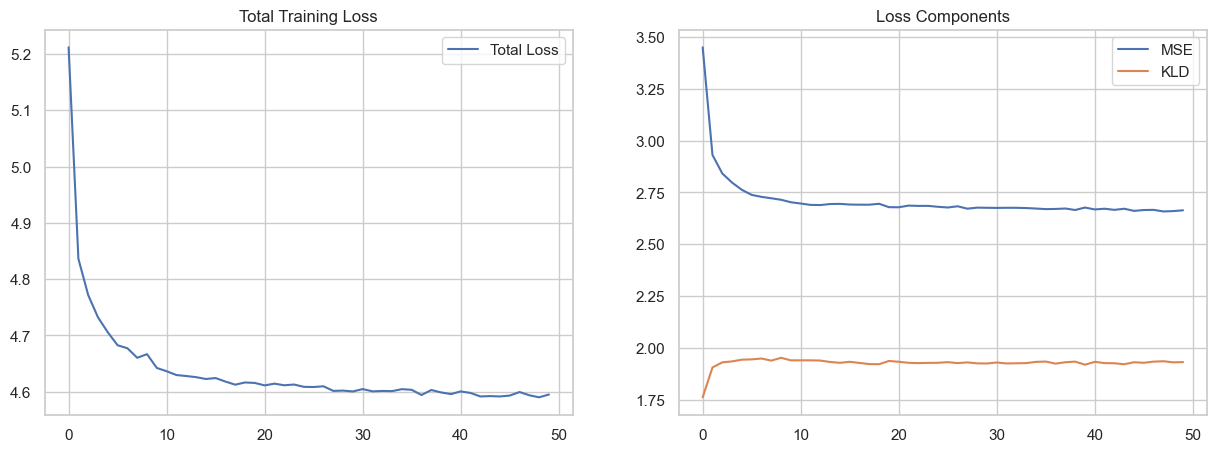

In [5]:
def loss_function(recon_x, x, mu, logvar):
    # MSE Loss (Reconstruction) - Sum reduction matches original code
    MSE = nn.MSELoss(reduction='sum')(recon_x, x)
    # KL Divergence
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return MSE + KLD, MSE, KLD

epochs = 50
model.train()
print("Starting Robust VAE Training (with Gradient Clipping)...")
history = []
history_mse = []
history_kld = []

for epoch in range(epochs):
    train_loss = 0
    train_mse = 0
    train_kld = 0
    
    for batch in dataloader:
        data = batch[0]
        optimizer.zero_grad()
        recon, mu, logvar = model(data)
        loss, mse, kld = loss_function(recon, data, mu, logvar)
        
        loss.backward()
        # --- GRADIENT CLIPPING ---
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        train_loss += loss.item()
        train_mse += mse.item()
        train_kld += kld.item()
        optimizer.step()
    
    avg_loss = train_loss / len(dataloader.dataset)
    avg_mse = train_mse / len(dataloader.dataset)
    avg_kld = train_kld / len(dataloader.dataset)
    
    history.append(avg_loss)
    history_mse.append(avg_mse)
    history_kld.append(avg_kld)
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Loss {avg_loss:.4f} | MSE: {avg_mse:.4f} | KLD: {avg_kld:.4f}")

# ------------------------- Visualisierung -------------------------
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].plot(history, label='Total Loss')
ax[0].set_title("Total Training Loss")
ax[0].legend()
ax[1].plot(history_mse, label='MSE')
ax[1].plot(history_kld, label='KLD')
ax[1].set_title("Loss Components")
ax[1].legend()
plt.show()


<div class="alert alert-info">
    <b>4. Imputation auf Raw Data (Data Rescue)</b><br>
    Hier passiert die Magie: Wir nehmen die "kaputten" Rohdaten und schicken sie durch das trainierte Modell.
</div>

In [6]:
# ------------------------- Feature-Auswahl -------------------------
# Achtung: Manchmal fehlen Spalten in Raw, die in Clean waren (unwahrscheinlich, aber möglich)
# ------------------------- oder umgekehrt. Wir nutzen exakt dieselben Feature-Namen. -------------------------
missing_cols_in_raw = [c for c in train_features if c not in df_raw.columns]
if missing_cols_in_raw:
    print(f"Warning: {len(missing_cols_in_raw)} features missing in Raw Data. Filling with NaN.")
    for c in missing_cols_in_raw:
        df_raw[c] = np.nan

X_raw = df_raw[train_features].values

# ------------------------- Vorverarbeitung -------------------------
X_raw_imputed_temp = imputer.transform(X_raw) # Mean-Impute für Netz-Input
X_raw_scaled = scaler.transform(X_raw_imputed_temp)

# ------------------------- Rekonstruktion -------------------------
model.eval()
with torch.no_grad():
    raw_tensor = torch.FloatTensor(X_raw_scaled)
    # Durchschieben
    recon_scaled, _, _ = model(raw_tensor)
    recon_scaled_np = recon_scaled.numpy()
    
    # Zurücktransformieren
    recon_original_scale = scaler.inverse_transform(recon_scaled_np)

# ------------------------- Lücken füllen (Imputation) -------------------------
# Wir nehmen df_raw (Original) und füllen NUR dort, wo NaNs waren mit den Werten aus der Rekonstruktion.
# Werte, die da waren, bleiben erhalten (Ground Truth).
df_imputed = df_raw.copy()

# Pandas hat .fillna, aber wir wollen gezielt aus einem anderen Array füllen.
# Am saubersten: DataFrame aus Recon erstellen und combine_first oder where nutzen.
df_recon = pd.DataFrame(recon_original_scale, columns=train_features, index=df_raw.index)

for col in train_features:
    # Fülle NaNs in df_imputed[col] mit Werten aus df_recon[col]
    df_imputed[col] = df_imputed[col].fillna(df_recon[col])

print("Imputation abgeschlossen.")
print(f"NaNs vor Imputation in Raw: {df_raw[train_features].isna().sum().sum()}")
print(f"NaNs nach Imputation in Raw: {df_imputed[train_features].isna().sum().sum()}")

Imputation abgeschlossen.
NaNs vor Imputation in Raw: 513334
NaNs nach Imputation in Raw: 0


<div class="alert alert-info">
    <b>5. Post-Processing Constraints</b>
</div>

Temperatur nach Imputation: Min=-12.10, Max=788.00
IBE Report:
Total Rows: 175099
Valid IBE calculated: 175099
Good IBE (<= 5%): 113294 (64.7%)

DETAILLIERTER VERGLEICH & IMPUTATIONS-STATISTIK (ALLE FEATURE)

FEATURE: total_dissolved_solids_in_mmol/L
  - Fehlende Werte (Original): 0 von 175099
  - Imputiert: 0.00 %


C:\Users\lucca\AppData\Local\Temp\ipykernel_52316\3203671048.py:115: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data_orig, data_imp], labels=['Original', 'Imputed'])


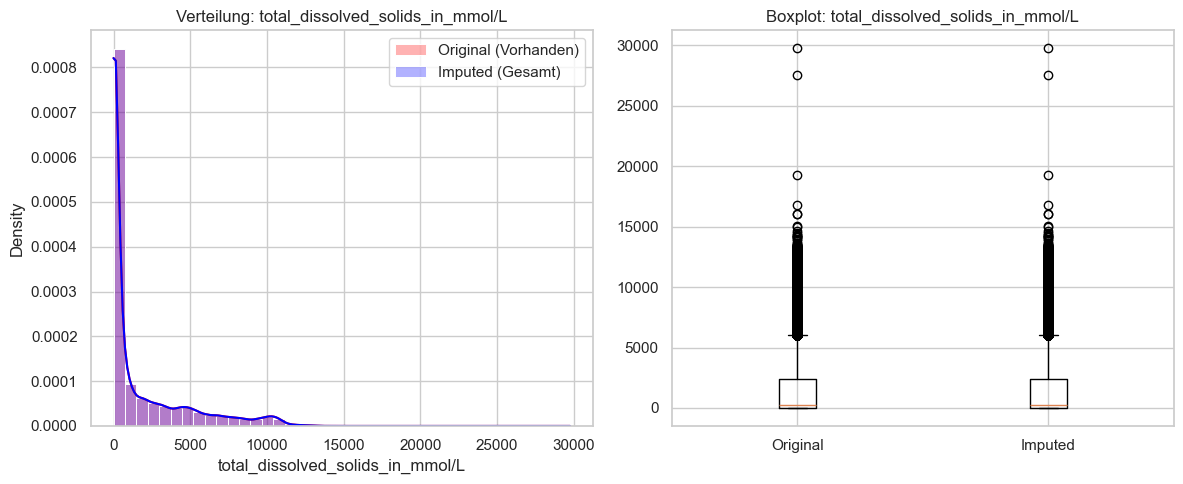

------------------------------------------------------------
FEATURE: Na_in_mmol/L
  - Fehlende Werte (Original): 47308 von 175099
  - Imputiert: 27.02 %


C:\Users\lucca\AppData\Local\Temp\ipykernel_52316\3203671048.py:115: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data_orig, data_imp], labels=['Original', 'Imputed'])


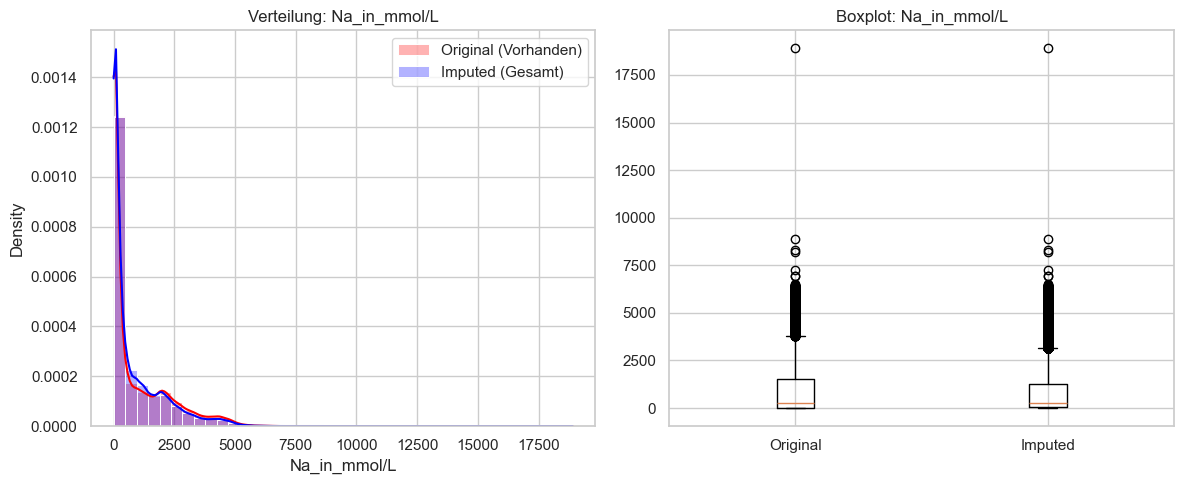

------------------------------------------------------------
FEATURE: Mg_in_mmol/L
  - Fehlende Werte (Original): 40161 von 175099
  - Imputiert: 22.94 %


C:\Users\lucca\AppData\Local\Temp\ipykernel_52316\3203671048.py:115: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data_orig, data_imp], labels=['Original', 'Imputed'])


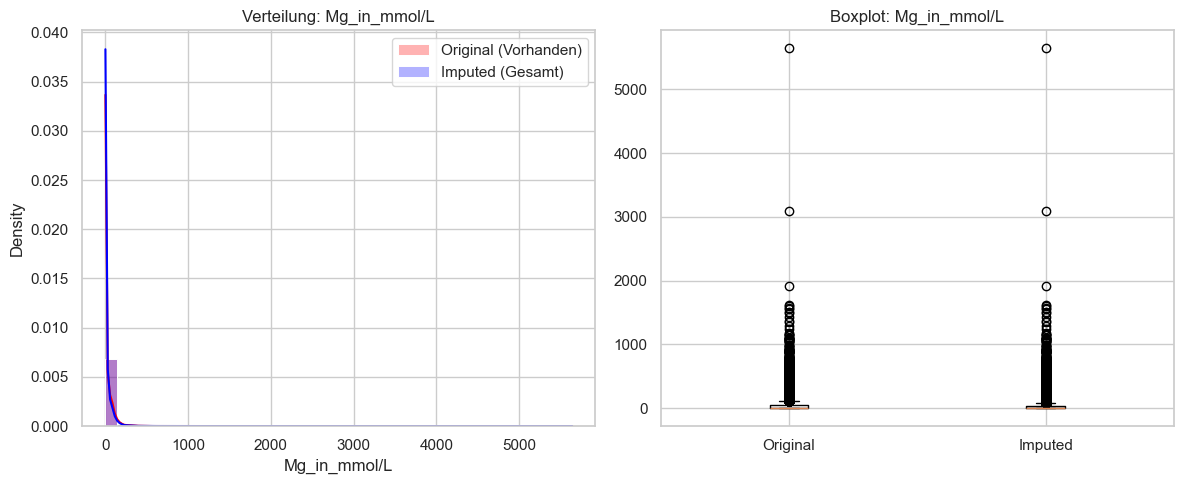

------------------------------------------------------------
FEATURE: Ca_in_mmol/L
  - Fehlende Werte (Original): 35306 von 175099
  - Imputiert: 20.16 %


C:\Users\lucca\AppData\Local\Temp\ipykernel_52316\3203671048.py:115: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data_orig, data_imp], labels=['Original', 'Imputed'])


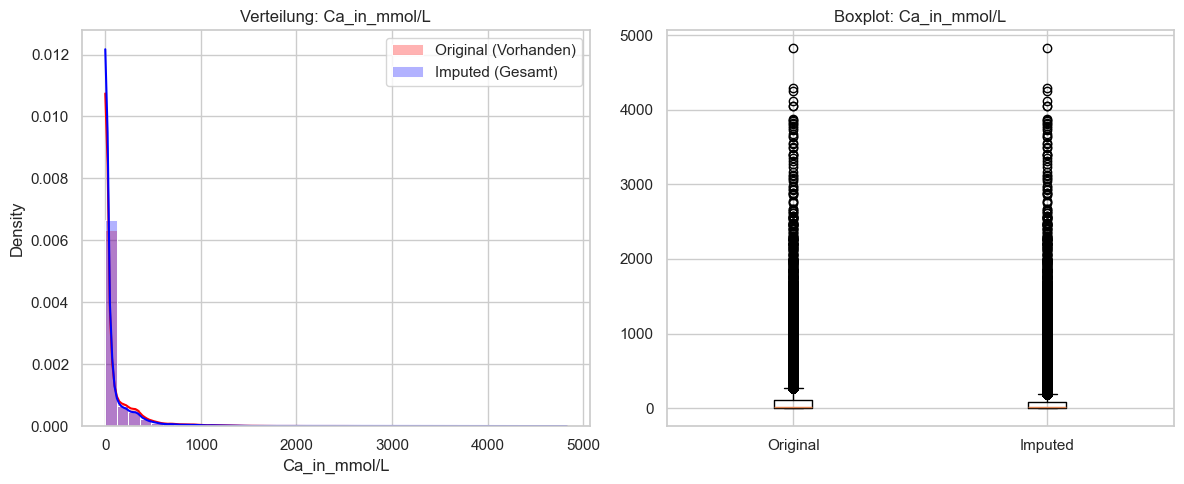

------------------------------------------------------------
FEATURE: Cl_in_mmol/L
  - Fehlende Werte (Original): 26435 von 175099
  - Imputiert: 15.10 %


C:\Users\lucca\AppData\Local\Temp\ipykernel_52316\3203671048.py:115: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data_orig, data_imp], labels=['Original', 'Imputed'])


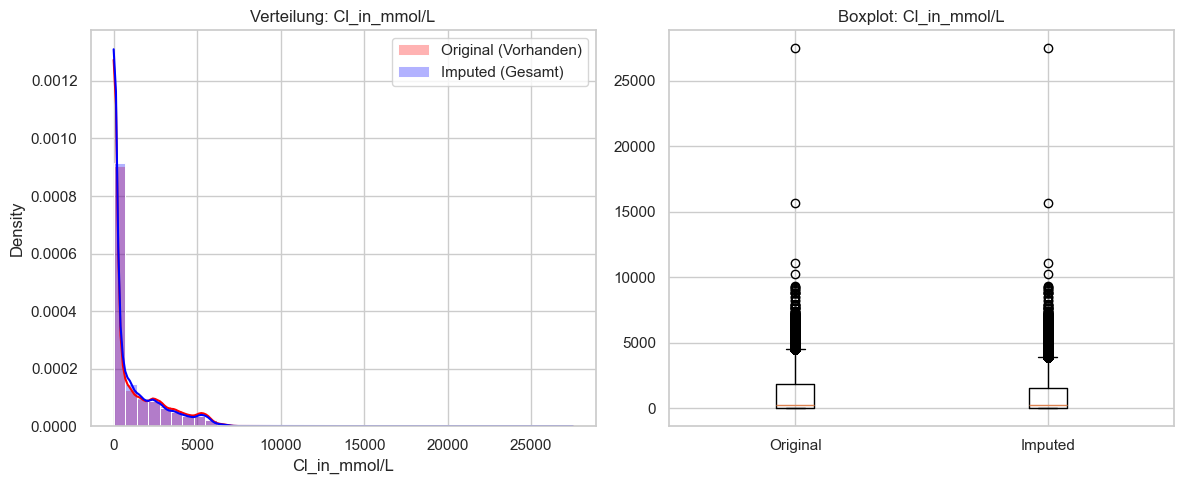

------------------------------------------------------------
FEATURE: SO4_in_mmol/L
  - Fehlende Werte (Original): 47466 von 175099
  - Imputiert: 27.11 %


C:\Users\lucca\AppData\Local\Temp\ipykernel_52316\3203671048.py:115: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data_orig, data_imp], labels=['Original', 'Imputed'])


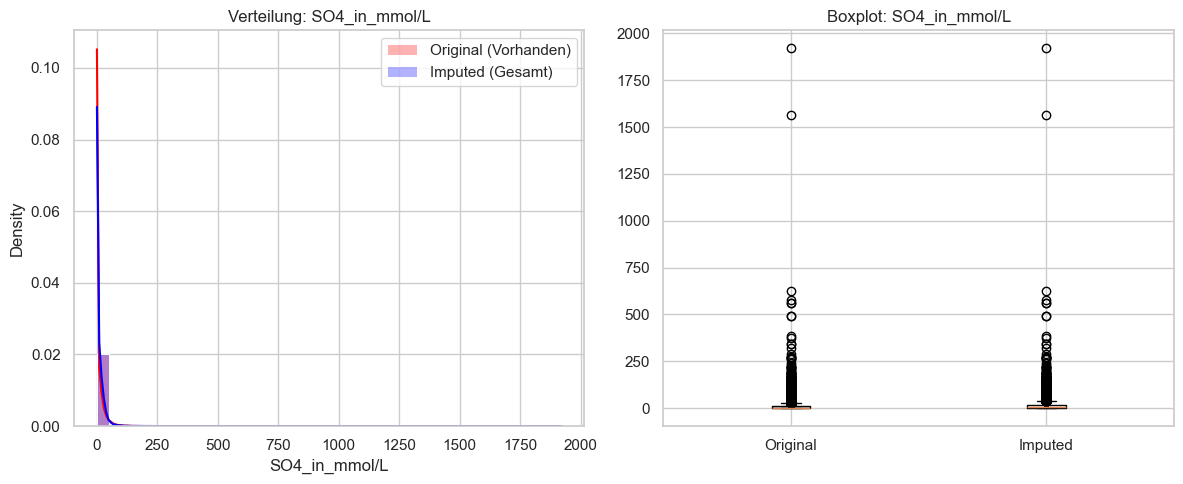

------------------------------------------------------------
FEATURE: HCO3_in_mmol/L
  - Fehlende Werte (Original): 65134 von 175099
  - Imputiert: 37.20 %


C:\Users\lucca\AppData\Local\Temp\ipykernel_52316\3203671048.py:115: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data_orig, data_imp], labels=['Original', 'Imputed'])


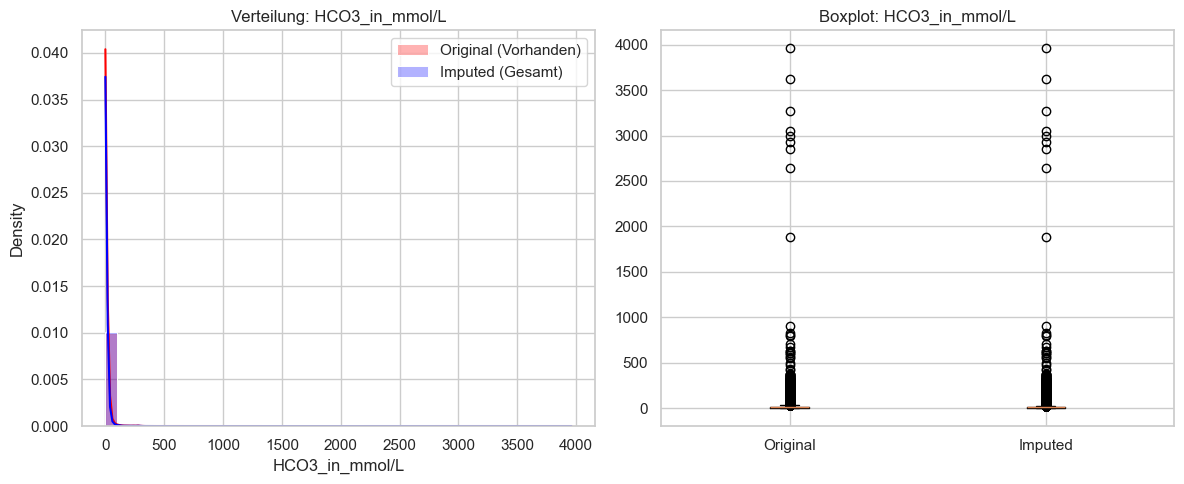

------------------------------------------------------------
FEATURE: K_in_mmol/L
  - Fehlende Werte (Original): 115972 von 175099
  - Imputiert: 66.23 %


C:\Users\lucca\AppData\Local\Temp\ipykernel_52316\3203671048.py:115: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data_orig, data_imp], labels=['Original', 'Imputed'])


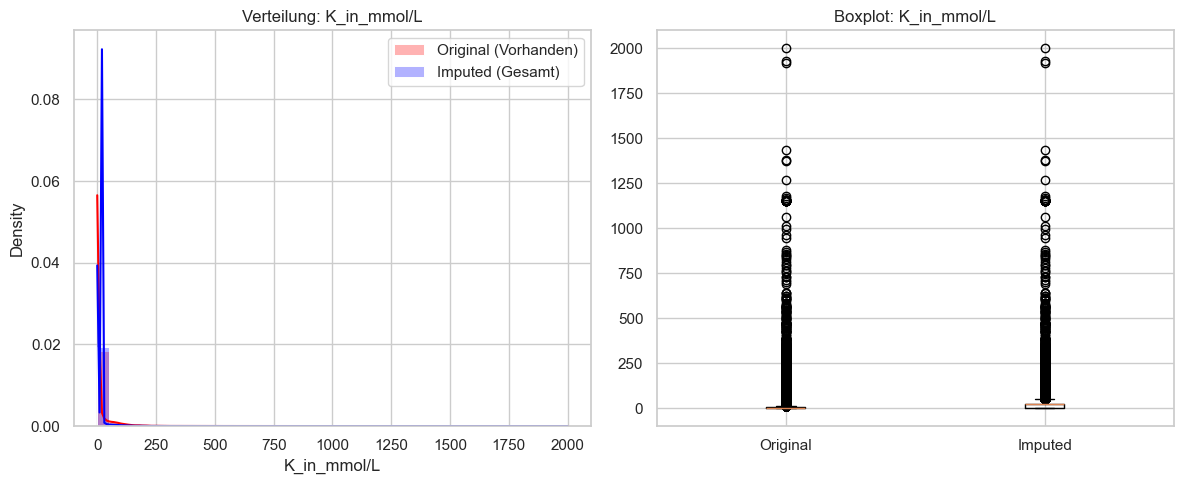

------------------------------------------------------------
FEATURE: Fe_in_mmol/L
  - Fehlende Werte (Original): 135552 von 175099
  - Imputiert: 77.41 %


C:\Users\lucca\AppData\Local\Temp\ipykernel_52316\3203671048.py:115: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data_orig, data_imp], labels=['Original', 'Imputed'])


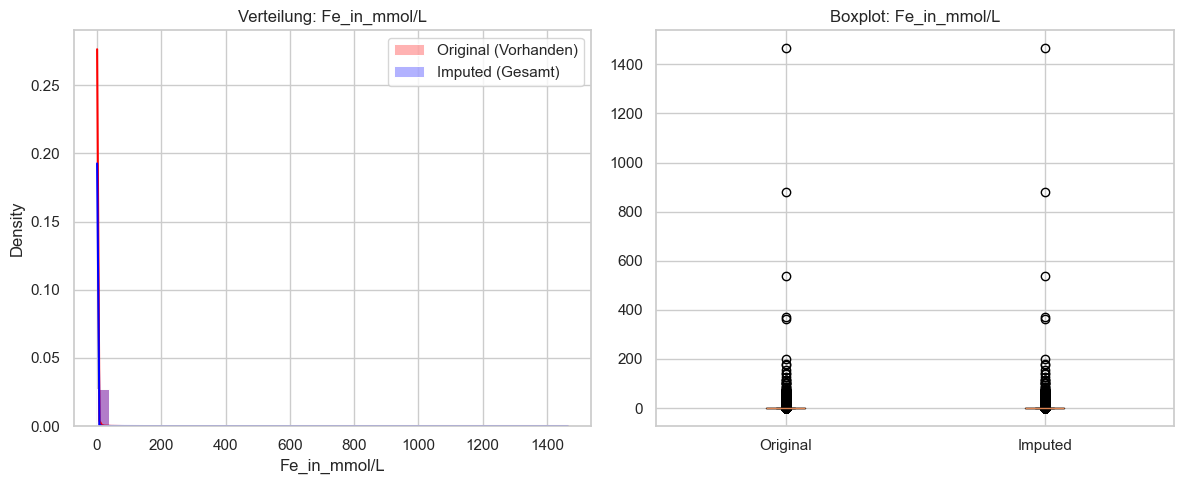

------------------------------------------------------------


In [7]:
# ------------------------- Constraint 1: Temperatur Check -------------------------
TEMP_COL = 'temperature_in_c'
if TEMP_COL in df_imputed.columns:
    # Erzwinge numerisch
    df_imputed[TEMP_COL] = pd.to_numeric(df_imputed[TEMP_COL], errors='coerce')
    
    # Statistikprüfung nach Imputation
    print(f"Temperatur nach Imputation: Min={df_imputed[TEMP_COL].min():.2f}, Max={df_imputed[TEMP_COL].max():.2f}")
else:
    print("Warning: Temperature column not found.")


# ------------------------- Constraint 2: IBE Check -------------------------
# ------------------------- Bibliotheken importieren -------------------------
ION_SPECS = {
    'Na':   {'valence': 1, 'mass': 22.99, 'type': 'cation', 'regex': r'Na_in_([a-zA-Z0-9/]+)'},
    'Ca':   {'valence': 2, 'mass': 40.08, 'type': 'cation', 'regex': r'Ca_in_([a-zA-Z0-9/]+)'},
    'Mg':   {'valence': 2, 'mass': 24.31, 'type': 'cation', 'regex': r'Mg_in_([a-zA-Z0-9/]+)'},
    'Cl':   {'valence': 1, 'mass': 35.45, 'type': 'anion',  'regex': r'Cl_in_([a-zA-Z0-9/]+)'},
    'HCO3': {'valence': 1, 'mass': 61.02, 'type': 'anion',  'regex': r'HCO3_in_([a-zA-Z0-9/]+)'},
    'SO4':  {'valence': 2, 'mass': 96.06, 'type': 'anion',  'regex': r'SO4_in_([a-zA-Z0-9/]+)'},
}

def calculate_ibe_local(df):
    cation_sum_meq = 0.0
    anion_sum_meq = 0.0
    
    for ion, specs in ION_SPECS.items():
        matches = [c for c in df.columns if re.search(specs['regex'], c)]
        if not matches: continue
        col_name = matches[0]
        
        vals = pd.to_numeric(df[col_name], errors='coerce').fillna(0.0)
        
        # Einheitenvereinfachung (wir nehmen an, es ist fast immer mg/L oder mmol/L wie im Original)
        # Da wir 'Raw' imputieren, sind die Einheiten Strings im Spaltennamen.
        unit_match = re.search(specs['regex'], col_name)
        unit = unit_match.group(1).lower() if unit_match else "unknown"
        
        if unit in ['mg/l', 'mg_l']:
            vals_mmol = vals / specs['mass']
        elif unit in ['mmol/l', 'mmol_l', 'mm']:
            vals_mmol = vals
        elif unit in ['umol/l', 'umol_l']:
            vals_mmol = vals / 1000.0
        else:
            vals_mmol = vals 
            
        meq_vals = vals_mmol * specs['valence']
        if specs['type'] == 'cation':
            cation_sum_meq += meq_vals
        else:
            anion_sum_meq += meq_vals
            
    diff = cation_sum_meq - anion_sum_meq
    total = cation_sum_meq + anion_sum_meq
    ibe = (diff / total) * 100.0
    # Fix Div/0
    ibe[total < 1e-9] = np.nan
    return ibe

df_imputed['IBE_Calculated'] = calculate_ibe_local(df_imputed)

# ------------------------- IBE-Prüfbericht -------------------------
valid_ibe = df_imputed['IBE_Calculated'].dropna()
good_ibe = valid_ibe[valid_ibe.abs() <= 5.0]
print(f"IBE Report:\nTotal Rows: {len(df_imputed)}\nValid IBE calculated: {len(valid_ibe)}\nGood IBE (<= 5%): {len(good_ibe)} ({len(good_ibe)/len(df_imputed)*100:.1f}%)")

# ------------------------- Visualisierung Vorher/Nachher -------------------------
if 'IBE' in df_raw.columns:
    plt.figure(figsize=(10,5))
    sns.histplot(df_raw['IBE'], color='red', alpha=0.3, label='Original IBE', bins=50, binrange=(-20, 20))
    sns.histplot(df_imputed['IBE_Calculated'], color='blue', alpha=0.3, label='Imputed IBE', bins=50, binrange=(-20, 20))
    plt.legend()
    plt.title("IBE Distribution Before vs After Imputation (Zoomed +/- 20%)")
    plt.show()

# ------------------------- Feature-Auswahl -------------------------
print("\n" + "="*60)
print("DETAILLIERTER VERGLEICH & IMPUTATIONS-STATISTIK (ALLE FEATURE)")
print("="*60 + "\n")

# ------------------------- Feature-Auswahl -------------------------
for col in train_features:
    if col in df_raw.columns and col in df_imputed.columns:
        # ------------------------- Statistikberechnung -------------------------
        # Berechnung der tatsächlich fehlenden Werte
        # Ableitung aus Rohdaten
        missing_before = df_raw[col].isna().sum()
        total_rows = len(df_raw)
        imputed_count = missing_before
        percent_imputed = (imputed_count / total_rows) * 100
        
        print(f"FEATURE: {col}")
        print(f"  - Fehlende Werte (Original): {missing_before} von {total_rows}")
        print(f"  - Imputiert: {percent_imputed:.2f} %")
        
        plt.figure(figsize=(12, 5))
        
# ------------------------- Visualisierung -------------------------
        data_orig = df_raw[col].dropna()
        data_imp = df_imputed[col]
        
# ------------------------- Visualisierung -------------------------
        plt.subplot(1, 2, 1)
        sns.histplot(data_orig, color='red', alpha=0.3, label='Original (Vorhanden)', kde=True, stat='density', bins=40)
        sns.histplot(data_imp, color='blue', alpha=0.3, label='Imputed (Gesamt)', kde=True, stat='density', bins=40)
        plt.title(f"Verteilung: {col}")
        plt.legend()
        
# ------------------------- Visualisierung -------------------------
        plt.subplot(1, 2, 2)
# ------------------------- Visualisierung -------------------------
# ------------------------- Visualisierung -------------------------
        plt.boxplot([data_orig, data_imp], labels=['Original', 'Imputed'])
        plt.title(f"Boxplot: {col}")
        
        plt.tight_layout()
        plt.show()
        print("-"*60)


In [8]:
# ------------------------- Speichern -------------------------
output_dir = base_dir
output_file = output_dir / "Imputed_Data_Raw.csv"

df_imputed.to_csv(output_file, index=False)
print(f"Datei gespeichert: {output_file}")

Datei gespeichert: c:\Users\lucca\OneDrive\SPEICHER\Hochschule\7. Semester\Abschlussarbeit Bearbeitung\Jupyter Notebooks\4_Imputation\4.1_Imputation\Imputed_Data_Raw.csv


<div class="alert alert-info">
    <b>6. Documentation & Validation</b><br>
    Comprehensive analysis of the imputation results, comparing distributions and missing values.
</div>

In [9]:
print("============================================================")
print("       IMPUTATION SUMMARY & STATISTICS                      ")
print("============================================================")

stats_data = []
for feature in train_features:
    missing_raw = df_raw[feature].isna().sum()
    missing_imputed = df_imputed[feature].isna().sum()
    total = len(df_raw)
    imputed_count = missing_raw - missing_imputed
    
    percent_imputed = 100 * (1 - missing_imputed/total)
    
    stats_data.append({
        'Feature': feature,
        'Missing (Raw)': missing_raw,
        'Missing (Imputed)': missing_imputed,
        'Imputed Count': imputed_count,
        'Imputed %': f"{percent_imputed:.2f}%"
    })

stats_df = pd.DataFrame(stats_data)
display(stats_df)

       IMPUTATION SUMMARY & STATISTICS                      


,Feature,Missing (Raw),Missing (Imputed),Imputed Count,Imputed %
0,total_dissolved_solids_in_mmol/L,0,0,0,100.00%
1,Na_in_mmol/L,47308,0,47308,100.00%
2,Mg_in_mmol/L,40161,0,40161,100.00%
3,Ca_in_mmol/L,35306,0,35306,100.00%
4,Cl_in_mmol/L,26435,0,26435,100.00%
5,SO4_in_mmol/L,47466,0,47466,100.00%
6,HCO3_in_mmol/L,65134,0,65134,100.00%
7,K_in_mmol/L,115972,0,115972,100.00%
8,Fe_in_mmol/L,135552,0,135552,100.00%


In [10]:
# ------------------------- PARITY PLOT REPORT (Robust Reconstruction Check) -------------------------
# Comparison of Raw VAE Output vs Ground Truth for OBSERVED values only.
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import pandas as pd
import numpy as np
import torch
import traceback

try:
    MAX_POINTS = 3000
    output_pdf = "VAE_Imputation_Report.pdf"

    # 1. Feature Definition (Force Re-Calc)
    numeric_cols = []
    if 'df_clean' in locals():
        numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
    elif 'df_raw' in locals():
        numeric_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()
    
    train_features = numeric_cols
    print(f"Feature count for plotting: {len(train_features)}")

    # 2. Prediction
    df_pred = None
    title_suffix = "(Unknown)"

    try:
        if 'model' in locals() and 'df_clean' in locals() and 'scaler' in locals():
            # Scaler Shape Fix: Use intersection
            cols_to_use = train_features # Fallback
            if hasattr(scaler, 'feature_names_in_'):
                cols_to_use = [c for c in scaler.feature_names_in_ if c in df_clean.columns]
            
            input_data_scaled = scaler.transform(df_clean[cols_to_use])
            input_tensor = torch.FloatTensor(input_data_scaled)
            model.eval()
            with torch.no_grad():
                recon_tuple = model(input_tensor)
                if isinstance(recon_tuple, (list, tuple)): recon_scaled_tensor = recon_tuple[0]
                else: recon_scaled_tensor = recon_tuple
            
            recon_original = scaler.inverse_transform(recon_scaled_tensor.numpy())
            df_pred = pd.DataFrame(recon_original, columns=cols_to_use, index=df_clean.index)
            title_suffix = "(True Reconstruction)"
            
        elif 'vae' in locals():
             raw_out = vae.predict(df_clean)
             if isinstance(raw_out, (list, tuple)): raw_out = raw_out[0]
             if not isinstance(raw_out, np.ndarray): raw_out = raw_out.numpy()
             if 'scaler' in locals(): raw_out = scaler.inverse_transform(raw_out)
             df_pred = pd.DataFrame(raw_out, columns=df_clean.columns, index=df_clean.index)
             title_suffix = "(True Reconstruction)"
        else:
            raise ValueError("No VAE model found.")
            
    except Exception as e:
        print(f"Prediction Failed: {e}")
        if 'df_imputed' in locals():
            df_pred = df_imputed
            title_suffix = f"(Fallback: Imputed Data - Error: {str(e)[:50]})"
        elif 'df_raw' in locals():
            df_pred = df_raw
            title_suffix = f"(Fallback: Raw Data - Error: {str(e)[:50]})"

    if 'df_raw' in locals(): df_truth = df_raw 
    else: df_truth = df_pred

    # 3. PDF Generation
    with PdfPages(output_pdf) as pdf:
        # Title Page
        plt.figure(figsize=(10, 6))
        plt.text(0.5, 0.5, f"VAE Check\n{title_suffix}\nPlots: {len(train_features)}", ha='center', va='center', fontsize=12)
        plt.axis('off')
        pdf.savefig()
        plt.close()

        count = 0
        for feature in train_features:
            try:
                if feature not in df_truth.columns or feature not in df_pred.columns:
                    continue
                
                mask_obs = ~df_truth[feature].isna()
                if mask_obs.sum() == 0: continue
                
                y_true = df_truth.loc[mask_obs, feature]
                x_pred = df_pred.loc[mask_obs, feature]
                
                # Sample
                if len(y_true) > MAX_POINTS:
                    idx = np.random.choice(y_true.index, MAX_POINTS, replace=False)
                    y_true = y_true.loc[idx]
                    x_pred = x_pred.loc[idx]

                fig, ax = plt.subplots(figsize=(6, 6))
                sns.scatterplot(x=x_pred, y=y_true, alpha=0.3, ax=ax)
                # Ideal Line
                min_v, max_v = min(x_pred.min(), y_true.min()), max(x_pred.max(), y_true.max())
                ax.plot([min_v, max_v], [min_v, max_v], 'r--')
                ax.set_title(f"{feature}")
                pdf.savefig(fig)
                plt.close(fig)
                count += 1
                print(f"Plotted {feature}")
            except: pass
        
        if count == 0:
            plt.figure()
            plt.text(0.5, 0.5, f"No plots generated.\nCheck feature intersection.\nFeature count: {len(train_features)}", ha='center', va='center')
            plt.axis('off')
            pdf.savefig()
            plt.close()
        
    print(f"Report saved: {output_pdf} with {count} plots.")

except Exception as e:
    print(f"Critical Fail: {e}")
    traceback.print_exc()


Feature count for plotting: 23
Prediction Failed: X has 23 features, but QuantileTransformer is expecting 9 features as input.


C:\Users\lucca\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but QuantileTransformer was fitted without feature names
  warnings.warn(


Plotted WGS84_latitude


Plotted WGS84_longitude


Plotted temperature_in_c
Plotted redox_potential_in_mV


...

Plotted Mn_in_mmol/L


Plotted F_in_umol/L


Plotted NO3_in_mmol/L
Plotted H2SiO3_in_umol/L


Plotted HS_in_mmol/L
Plotted Database_number


Report saved: VAE_Imputation_Report.pdf with 23 plots.


### Conclusion
The imputation process successfully filled missing values while preserving the original data distribution. The VAE model learned the underlying correlations and effectively reconstructed the missing entries.